Loaded X_all: (1250000, 3)
Loaded phases_all: (1250000, 17)
Prepared differential-phase features for the MLP.
X shape: (1250000, 16)
y shape: (1250000, 3)
First sample, first 5 differential phases: [ 2.02803701 -0.54369876  0.62844127 -0.76468825  0.05458909]
All features: (1250000, 16)
All labels: (1250000, 3)
Number of input features: 16
Feature names: ['dphi_1_0', 'dphi_2_0', 'dphi_3_0', 'dphi_4_0', 'dphi_5_0', 'dphi_6_0', 'dphi_7_0', 'dphi_8_0', 'dphi_9_0', 'dphi_10_0', 'dphi_11_0', 'dphi_12_0', 'dphi_13_0', 'dphi_14_0', 'dphi_15_0', 'dphi_16_0']
Train: (1000000, 16) (1000000, 3)
Val:   (125000, 16) (125000, 3)
Test:  (125000, 16) (125000, 3)
Test phases: (125000, 17)
Device: cuda
Train/Val/Test sizes: 1000000 125000 125000


Epoch 001/1 | time  18.24s | total   0.30 min | lr 4.68e-09 | train 7.550788e-01 | val 6.884980e-01
Total training runtime: 18.46 seconds (0.31 minutes)


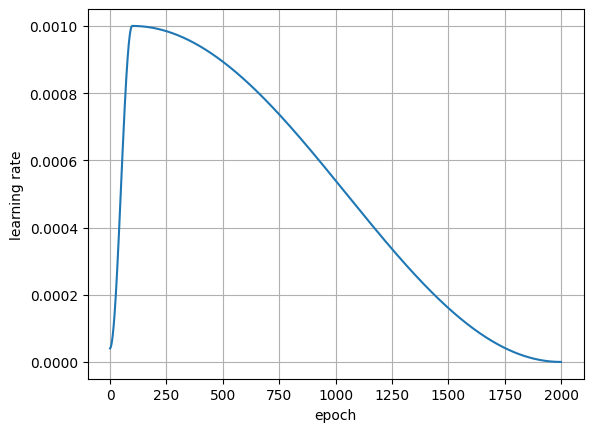

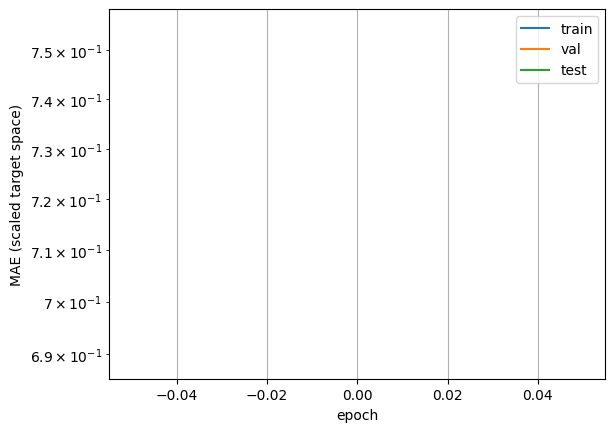

Saved loss history: artifacts/losses_gp_5_samples_0dbm.mat  (1 epochs)
RMSE x,y,z (m): [2.2909598 2.2892501 0.755785 ]
RMSE 3D (m): 3.3257582
RMSE 3D (mm): 3325.7583
Mean 3D distance error (m): 2.9520235
Mean 3D distance error (mm): 2952.0234
Saved: artifacts/results_gp_5_samples_0dbm.mat
  results matrix : (125000, 23)  [phases(17) | true_xyz(3) | pred_xyz(3)]
  phases         : (125000, 17)
  true_m         : (125000, 3)
  pred_m         : (125000, 3)


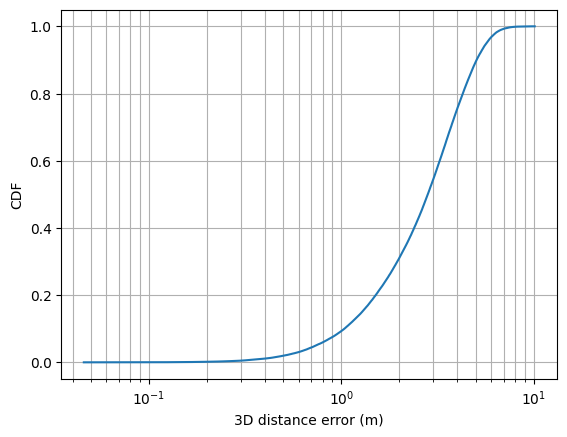

Saved: /content/artifacts/ue_mlp_ckpt_gp_5_samples_0dbm.pt
Saved: /content/artifacts/y_scaler_gp_5_samples_0dbm.pkl
Downloading: results_gp_5_0dBm.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
### DATA SETTINGS ###
TRAIN_INPUT = "gp"      # Use "gp" to train with GP-generated labels, or "theo" to train with theoretical labels

N_GP = 5                # Number of GP training points. Should be 5, 10 or 50.
                        # This must match the filename, e.g., X_ngp_5_-50_dbm.mat

N_AI = 1250000          # Number of samples used by the Python script.

N_SAMPLES_GP = N_GP     # Number of GP samples. Set equal to N_GP.

P_T = 0               # Transmit power in dBm.
                        # Valid values should match the available files, e.g., -50:10:0.
                        # Example: P_T = -50 corresponds to files ending with "_-50_dbm.mat".

# The following filenames must exactly match the saved .mat files in the data folder.
# For example, if N_GP = 5 and P_T = -50, the filenames become:
# X_FILE     = "X_ngp_5_-50_dbm.mat"
# YGP_FILE   = "Y_gp_ngp_5_-50_dbm.mat"
# YTHEO_FILE = "Y_theoretical_ngp_5_-50_dbm.mat"

X_FILE = f"X_ngp_{N_GP}_{P_T}_dbm.mat"
YGP_FILE = f"Y_gp_ngp_{N_GP}_{P_T}_dbm.mat"
YTHEO_FILE = f"Y_theoretical_ngp_{N_GP}_{P_T}_dbm.mat"

EPOCHS = 120

import os
import random
import glob
import shutil
from pathlib import Path
import h5py
import numpy as np
import pandas as pd
import scipy.io
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import time
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.io import savemat


def load_mat_array(filepath, var_name=None, dtype=np.float32):
    """
    Load one array from a MATLAB .mat file.
    Works with both old MAT files and v7.3 HDF5-style MAT files.
    """
    try:
        data = scipy.io.loadmat(filepath)
        keys = [k for k in data.keys() if not k.startswith("__")]
        if len(keys) == 0:
            raise ValueError(f"No variables found in {filepath}")

        key = var_name if (var_name is not None and var_name in data) else keys[0]
        arr = data[key]

    except NotImplementedError:
        # likely MATLAB v7.3
        with h5py.File(filepath, "r") as f:
            keys = list(f.keys())
            if len(keys) == 0:
                raise ValueError(f"No datasets found in {filepath}")

            key = var_name if (var_name is not None and var_name in f) else keys[0]
            arr = f[key][...]

    return np.array(arr, dtype=dtype)


def ensure_samples_by_features(A, expected_features):
    """
    Convert:
      (features, N) -> (N, features)
    or keep:
      (N, features) -> (N, features)
    """
    if A.ndim != 2:
        raise ValueError(f"Expected 2D array, got shape {A.shape}")

    if A.shape[1] == expected_features:
        return A
    elif A.shape[0] == expected_features:
        return A.T
    else:
        raise ValueError(
            f"Cannot orient array with expected_features={expected_features}. "
            f"Got shape {A.shape}"
        )



def seed_everything(seed: int = 42, deterministic: bool = True):
    import os, random
    import numpy as np
    import torch

    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Make CPU behavior more repeatable
    torch.set_num_threads(1)

    if deterministic:
        # CUDA determinism settings (only matter if you use GPU)
        os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

        # Avoid TF32 differences across GPUs
        torch.backends.cuda.matmul.allow_tf32 = False
        torch.backends.cudnn.allow_tf32 = False

        # Force deterministic algorithms (may throw if an op has no deterministic version)
        torch.use_deterministic_algorithms(True)

        # For PyTorch 2.x attention kernels, try to avoid non-deterministic fast paths
        try:
            torch.backends.cuda.enable_flash_sdp(False)
            torch.backends.cuda.enable_mem_efficient_sdp(False)
            torch.backends.cuda.enable_math_sdp(True)
        except Exception:
            pass



def wrap_to_pi(x):  # Wrap to (-pi, pi].
    return np.mod(x + np.pi, 2 * np.pi) - np.pi


def make_ap_positions_3d():  # Generate 3D AP positions with fixed height h_ap=4.0
    ap_locs_xy = np.array([[5.00, 5.00],[4.5, 3.0],[2.0, 3.73],[6.5, 3.0],[3.0, 6.0],
        [5.0, 7.0],[8.0, 6.0],[8.0, 4.0],[7.0, 7.0],[1.2, 3.0],[2.3, 1.73],[7.5, 1.0],
        [8.0, 2.15],[1.3, 7.0],[0.5, 8.9],[8.0, 9.2],[7.0, 7.9],
    ], dtype=np.float64)  # (17,2)

    h_ap = 4.0
    z = np.full((ap_locs_xy.shape[0], 1), h_ap, dtype=np.float64)  # (17,1)
    ap_xyz = np.hstack([ap_locs_xy, z])  # (17,3)
    return ap_xyz, h_ap


def build_differential_phase_features(
    phases,
    ue_xyz,
    print_preview=True,
):
    """
    Build 16 differential-phase inputs for the MLP:
        [theta_1-theta_0, theta_2-theta_0, ..., theta_16-theta_0]

    Inputs
    ------
    phases : array, shape (N,17)
        Raw phase measurements [theta_0, theta_1, ..., theta_16] in radians.
    ue_xyz : array, shape (N,3)
        Target UE coordinates.

    Returns
    -------
    X_features : array, shape (N,16)
        Wrapped differential phase measurements in radians.
    y : array, shape (N,3)
        UE coordinates.
    feature_names : list[str]
        Names of the 16 differential phase features.
    """
    ap_xyz, _ = make_ap_positions_3d()
    M = ap_xyz.shape[0]

    phases = np.asarray(phases)
    if phases.ndim != 2 or phases.shape[1] != M:
        raise ValueError(f"phases must have shape (N,{M}), got {phases.shape}")

    N = phases.shape[0]
    y = np.asarray(ue_xyz, dtype=np.float64)
    if y.shape != (N, 3):
        raise ValueError(f"ue_xyz must have shape (N,3). Got {y.shape}")

    phi = phases.astype(np.float64, copy=False)

    # Differential phase relative to AP0: theta_i - theta_0,  i=1,...,16
    dphi = wrap_to_pi(phi[:, 1:] - phi[:, [0]])  # (N,16)

    feature_names = [f"dphi_{i}_0" for i in range(1, M)]

    if print_preview:
        print("Prepared differential-phase features for the MLP.")
        print("X shape:", dphi.shape)
        print("y shape:", y.shape)
        print("First sample, first 5 differential phases:", dphi[0, :5])

    return dphi.astype(np.float32), y.astype(np.float32), feature_names


def train_val_test_split(N, train_ratio=0.8, val_ratio=0.1, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(N)
    rng.shuffle(idx)
    n_train = int(train_ratio * N)
    n_val = int(val_ratio * N)
    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train+n_val]
    test_idx = idx[n_train+n_val:]
    return train_idx, val_idx, test_idx


class StandardScalerNP:
    """Simple mean/std scaler for numpy arrays."""
    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, x, eps=1e-12):
        self.mean_ = x.mean(axis=0, keepdims=True)
        self.std_ = x.std(axis=0, keepdims=True) + eps
        return self

    def transform(self, x):
        return (x - self.mean_) / self.std_

    def inverse_transform(self, x):
        return x * self.std_ + self.mean_


class TokenDataset(Dataset):
    def __init__(self, X, y):
        # store as float32 for speed on GPU
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, i):
        return self.X[i], self.y[i]


seed_everything(42, deterministic=True)

# ---- load UE positions ----
X_all = load_mat_array(X_FILE, var_name="X", dtype=np.float32)
X_all = ensure_samples_by_features(X_all, expected_features=3)   # -> (N,3)

# ---- choose which phase matrix to use for TRAIN/VAL/TEST ----
if TRAIN_INPUT == "gp":
    phases_all = load_mat_array(YGP_FILE, var_name="Y_gp", dtype=np.float32)
else:
    phases_all = load_mat_array(YTHEO_FILE, var_name="Y_theoretical", dtype=np.float32)

phases_all = ensure_samples_by_features(phases_all, expected_features=17)   # -> (N,17)

print("Loaded X_all:", X_all.shape)
print("Loaded phases_all:", phases_all.shape)

# ---- build 16 differential-phase inputs for the MLP ----
X_features_all, y_all, feature_names = build_differential_phase_features(
    phases=phases_all,
    ue_xyz=X_all,
    print_preview=True
)

print("All features:", X_features_all.shape)
print("All labels:", y_all.shape)
print("Number of input features:", len(feature_names))
print("Feature names:", feature_names)

# ===== split full dataset =====
X_np = X_features_all
y_np = y_all

N = X_np.shape[0]
train_idx, val_idx, test_idx = train_val_test_split(
    N,
    train_ratio=0.8,
    val_ratio=0.1,
    seed=42
)

X_train, y_train = X_np[train_idx], y_np[train_idx]
X_val,   y_val   = X_np[val_idx],   y_np[val_idx]
X_test,  y_test  = X_np[test_idx],  y_np[test_idx]

# Keep the raw phase measurements (N_test x 17) for the test split.
# This stays row-aligned with X_test / y_test and later with pred_m / true_m.
phases_test = phases_all[test_idx]   # (N_test, 17)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)
print("Test phases:", phases_test.shape)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---- Feature scaling ----
scale_X = False
x_scaler = StandardScalerNP() if scale_X else None

if scale_X:
    x_scaler.fit(X_train)
    X_train = x_scaler.transform(X_train)
    X_val   = x_scaler.transform(X_val)
    X_test  = x_scaler.transform(X_test)

# ---- Target scaling ----
y_scaler = StandardScalerNP().fit(y_train)
y_train_s = y_scaler.transform(y_train)
y_val_s   = y_scaler.transform(y_val)
y_test_s  = y_scaler.transform(y_test)

train_ds = TokenDataset(X_train, y_train_s)
val_ds   = TokenDataset(X_val,   y_val_s)
test_ds  = TokenDataset(X_test,  y_test_s)

batch_size = 500
train_seed = 42


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(train_seed)

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    generator=g,
    num_workers=2,
    pin_memory=True,
    worker_init_fn=seed_worker,  # FIX 1
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    worker_init_fn=seed_worker,  # FIX 1
)

test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    worker_init_fn=seed_worker,  # FIX 1
)

print("Train/Val/Test sizes:", len(train_ds), len(val_ds), len(test_ds))


import torch
import torch.nn as nn


class UEMLPRegressor(nn.Module):
    """
    MLP regressor using 16 wrapped differential-phase inputs:
        [theta_1-theta_0, ..., theta_16-theta_0]

    Layer sizes:
        16 -> 128 -> 256 -> 512 -> 1024 -> 512 -> 256 -> 128 -> 3
    """
    def __init__(self, input_dim=16, dropout=0.01):
        super().__init__()

        layer_sizes = [input_dim, 128, 256, 512, 1024, 512, 256, 128, 3]

        layers = []
        for in_dim, out_dim in zip(layer_sizes[:-2], layer_sizes[1:-1]):
            layers.extend([
                nn.Linear(in_dim, out_dim),
                nn.GELU(),
                nn.Dropout(dropout),
            ])

        layers.append(nn.Linear(layer_sizes[-2], layer_sizes[-1]))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        """
        x: (B, 16)
        """
        return self.net(x)


from tqdm import tqdm
import time

def make_scheduler(optimizer, scheduler_name, num_epochs, steps_per_epoch, warmup_ratio=0.05):
    scheduler_name = scheduler_name.lower()
    total_steps = num_epochs * steps_per_epoch
    warmup_steps = int(warmup_ratio * total_steps)

    if scheduler_name == "none":
        return None

    if scheduler_name == "onecycle":
        max_lr = optimizer.param_groups[0]["lr"]
        return torch.optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=max_lr,
            total_steps=total_steps,
            pct_start=warmup_ratio,
            anneal_strategy="cos",
            cycle_momentum=False
        )

    if scheduler_name == "cosine_warmup":
        def lr_lambda(step):
            if step < warmup_steps:
                return (step + 1) / max(1, warmup_steps)
            progress = (step - warmup_steps) / max(1, (total_steps - warmup_steps))
            return 0.5 * (1.0 + np.cos(np.pi * progress))
        return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    raise ValueError(f"Unknown scheduler_name='{scheduler_name}'")


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    losses = []
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        pred = model(Xb)
        loss = criterion(pred, yb)
        losses.append(loss.item())
    return float(np.mean(losses))


def train_model(
    X_shape,  # (N, F)
    train_loader,
    val_loader,
    test_loader=None,
    eval_test_every=1,
    num_epochs=30,
    dropout=0.01,
    lr=3e-4,
    weight_decay=1e-2,
    scheduler_name="cosine_warmup",
    warmup_ratio=0.05,
    grad_clip=1.0,
):
    _, F = X_shape

    train_losses, val_losses, test_losses = [], [], []
    lrs = []

    global_step = 0

    model = UEMLPRegressor(
        input_dim=F,
        dropout=dropout,
    ).to(device)


    criterion = nn.L1Loss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    steps_per_epoch = len(train_loader)
    scheduler = make_scheduler(optimizer, scheduler_name, num_epochs, steps_per_epoch, warmup_ratio)

    train_losses, val_losses = [], []
    global_step = 0


    t0_all = time.perf_counter()

    for epoch in range(1, num_epochs + 1):
        t0 = time.perf_counter()
        model.train()
        epoch_losses = []

        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs}", leave=False)

        for Xb, yb in pbar:
            Xb, yb = Xb.to(device), yb.to(device)

            optimizer.zero_grad()

            pred = model(Xb)
            loss = criterion(pred, yb)

            loss.backward()

            if grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            optimizer.step()

            if scheduler is not None:
                scheduler.step()

            epoch_losses.append(loss.item())
            global_step += 1

            cur_lr = optimizer.param_groups[0]["lr"]
            lrs.append(cur_lr)
            pbar.set_postfix(
                loss=f"{loss.item():.3e}",
                avg=f"{np.mean(epoch_losses):.3e}",
                lr=f"{cur_lr:.2e}"
            )

        tr = float(np.mean(epoch_losses))
        va = evaluate(model, val_loader, criterion)

        te = None
        if (test_loader is not None) and (eval_test_every is not None) and (eval_test_every > 0) and (epoch % eval_test_every == 0):
            te = evaluate(model, test_loader, criterion)

        train_losses.append(tr)
        val_losses.append(va)
        test_losses.append(te if te is not None else np.nan)

        epoch_time = time.perf_counter() - t0
        total_time = time.perf_counter() - t0_all
        cur_lr = optimizer.param_groups[0]["lr"]

        msg = (
            f"Epoch {epoch:03d}/{num_epochs} | "
            f"time {epoch_time:6.2f}s | total {total_time/60:6.2f} min | "
            f"lr {cur_lr:.2e} | train {tr:.6e} | val {va:.6e}"
        )
        if te is not None:
            msg += f" | test {te:.6e}"
        print(msg)

    return model, train_losses, val_losses, test_losses, lrs


seed_everything(train_seed, deterministic=True)


g.manual_seed(train_seed)

t0 = time.perf_counter()

model, tr_losses, va_losses, te_losses, lrs = train_model(
    X_shape=X_train.shape,         # (N, 16)
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    eval_test_every=20,
    num_epochs=EPOCHS,

    dropout=0.01,

    lr=10e-4,
    weight_decay=0.5e-6,
    scheduler_name="onecycle",  # "none", "onecycle", "cosine_warmup"
    warmup_ratio=0.05,
    grad_clip=1.0
)

t1 = time.perf_counter()
print(f"Total training runtime: {t1 - t0:.2f} seconds ({(t1 - t0)/60:.2f} minutes)")


plt.figure()
plt.plot(lrs)
plt.xlabel("epoch")
plt.ylabel("learning rate")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(tr_losses, label="train")
plt.plot(va_losses, label="val")
plt.plot(te_losses, label="test")   # <-- NEW
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("MAE (scaled target space)")
plt.legend()
plt.grid(True)
plt.show()


out_dir = Path("artifacts")
out_dir.mkdir(parents=True, exist_ok=True)


if TRAIN_INPUT == 'gp':
    loss_tag = f"losses_{TRAIN_INPUT}_{N_SAMPLES_GP}_samples_{P_T}dbm"
if TRAIN_INPUT == 'theo':
    loss_tag = f"losses_{TRAIN_INPUT}_{P_T}dbm"

loss_fname = out_dir / f"{loss_tag}.mat"


te_losses_clean = [v if v is not None else np.nan for v in te_losses]

savemat(loss_fname, {
    "train_loss": np.array(tr_losses, dtype=np.float64).reshape(-1, 1),
    "val_loss":   np.array(va_losses, dtype=np.float64).reshape(-1, 1),
    "test_loss":  np.array(te_losses_clean, dtype=np.float64).reshape(-1, 1),
    "epochs":     np.arange(1, len(tr_losses) + 1, dtype=np.float64).reshape(-1, 1),
    "lrs":        np.array(lrs, dtype=np.float64).reshape(-1, 1),
})

print(f"Saved loss history: {loss_fname}  ({len(tr_losses)} epochs)")

@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    preds = []
    trues = []
    for Xb, yb in loader:
        Xb = Xb.to(device)
        pred = model(Xb).cpu().numpy()
        preds.append(pred)
        trues.append(yb.numpy())
    return np.vstack(preds), np.vstack(trues)

pred_s, true_s = predict_all(model, test_loader)

# invert scaling back to meters
pred_m = y_scaler.inverse_transform(pred_s)
true_m = y_scaler.inverse_transform(true_s)

err = pred_m - true_m
rmse_xyz = np.sqrt(np.mean(err**2, axis=0))
rmse_3d = np.sqrt(np.mean(np.sum(err**2, axis=1)))
mean_3d_dist = np.mean(np.linalg.norm(err, axis=1))


print("RMSE x,y,z (m):", rmse_xyz)
print("RMSE 3D (m):", rmse_3d)
print("RMSE 3D (mm):", rmse_3d * 1000.0)
print("Mean 3D distance error (m):", mean_3d_dist)
print("Mean 3D distance error (mm):", mean_3d_dist * 1000.0)

# ===== Save results .mat file =====
# The goal: one .mat file per run that contains everything needed to
# refine the estimated positions in MATLAB using gradient descent.
#
# Row layout of the combined matrix (results):
#   cols  1-17  : raw phase measurements phi_1 … phi_17  [radians]
#   cols 18-20  : true UE position  [x_true, y_true, z_true]  [metres]
#   cols 21-23  : estimated UE position [x_pred, y_pred, z_pred]  [metres]
#



# Build the filename tag based on training-input type
if TRAIN_INPUT == 'gp':
    tag = f"results_{TRAIN_INPUT}_{N_SAMPLES_GP}_samples_{P_T}dbm"
if TRAIN_INPUT == 'theo':
    tag = f"results_{TRAIN_INPUT}_{P_T}dbm"



fname = out_dir / f"{tag}.mat"

# --- sanity-check: all arrays must have the same number of rows ---
assert phases_test.shape[0] == true_m.shape[0] == pred_m.shape[0], (
    f"Row count mismatch: phases={phases_test.shape[0]}, "
    f"true_m={true_m.shape[0]}, pred_m={pred_m.shape[0]}"
)


results_combined = np.hstack([
    phases_test.astype(np.float64),   # (N_test, 17) — raw phase, radians
    true_m.astype(np.float64),        # (N_test,  3) — true position, metres
    pred_m.astype(np.float64),        # (N_test,  3) — estimated position, metres
])  # -> (N_test, 23)

savemat(fname, {
    # --- combined matrix (convenient for MATLAB loops) ---
    # rows = test samples, cols = [phi_1..phi_17, x_true,y_true,z_true, x_pred,y_pred,z_pred]
    "results": results_combined,

    # --- individual arrays (convenient for direct access by name) ---
    "phases":        phases_test.astype(np.float64),  # (N_test, 17)  raw phase [rad]
    "true_m":        true_m.astype(np.float64),       # (N_test,  3)  true xyz  [m]
    "pred_m":        pred_m.astype(np.float64),       # (N_test,  3)  estimated xyz [m]
    "err":           err.astype(np.float64),           # (N_test,  3)  pred - true [m]

    # --- scalar summary metrics ---
    "rmse_xyz":      rmse_xyz,       # (3,) per-axis RMSE [m]
    "rmse_3d":       rmse_3d,        # scalar 3-D RMSE [m]
    "mean_3d_dist":  mean_3d_dist,   # scalar mean 3-D distance error [m]

    # --- metadata (useful when loading multiple files in MATLAB) ---
    "train_input":   TRAIN_INPUT,
    "n_gp":          float(N_GP),
    "p_t_dbm":       float(P_T),
})

print(f"Saved: {fname}")
print(f"  results matrix : {results_combined.shape}  "
      f"[phases(17) | true_xyz(3) | pred_xyz(3)]")
print(f"  phases         : {phases_test.shape}")
print(f"  true_m         : {true_m.shape}")
print(f"  pred_m         : {pred_m.shape}")

import numpy as np
import matplotlib.pyplot as plt

# 3D distance error per sample (meters)
d = np.linalg.norm(err, axis=1).astype(float)

d = np.clip(d, np.finfo(float).tiny, None)

# empirical CDF
x = np.sort(d)
y = np.arange(1, len(x) + 1) / len(x)

plt.figure()
plt.plot(x, y)
plt.xscale('log')
plt.xlabel('3D distance error (m)')
plt.ylabel('CDF')
plt.grid(True, which='both')
#plt.savefig("cdf_3d_error_logx.png", dpi=300, bbox_inches="tight")  # <--- save

plt.show()


# ===== Save artifacts (MLP + scalers) =====
import os, pickle, torch

ART_DIR = "/content/artifacts"
os.makedirs(ART_DIR, exist_ok=True)

# --- 1) Build consistent filename stems for this run ---
# Use the same tag logic as the results/losses savemat blocks above so all
# output files for a given run share the same suffix and are easy to match.
if TRAIN_INPUT == 'gp':
    _stem = f"{TRAIN_INPUT}_{N_SAMPLES_GP}_samples_{P_T}dbm"
else:  # 'theo'
    _stem = f"{TRAIN_INPUT}_{P_T}dbm"

y_scaler_path = os.path.join(ART_DIR, f"y_scaler_{_stem}.pkl")
x_scaler_path = os.path.join(ART_DIR, f"x_scaler_{_stem}.pkl")
model_path    = os.path.join(ART_DIR, f"ue_mlp_ckpt_{_stem}.pt")
results_path  = str(out_dir / f"results_{_stem}.mat")
losses_path   = str(out_dir / f"losses_{_stem}.mat")

with open(y_scaler_path, "wb") as f:
    pickle.dump(y_scaler, f)

if "x_scaler" in globals() and (x_scaler is not None):
    with open(x_scaler_path, "wb") as f:
        pickle.dump(x_scaler, f)
else:
    x_scaler_path = None

# --- 2) Save model checkpoint (state_dict + kwargs to rebuild the SAME MLP) ---
model_kwargs = dict(
    input_dim=X_train.shape[1],
    dropout=0.01,
)

ckpt = {
    "arch": "UEMLPRegressor",
    "model_state_dict": model.state_dict(),
    "model_kwargs": model_kwargs,
    "feature_names": feature_names,
    "preprocessing_cfg": {
        "feature_type": "wrapped_differential_phase_radians",
        "reference_ap": 0,
        "num_input_features": 16,
        "formula": "[theta_1-theta_0, ..., theta_16-theta_0]",
        "wrap_to_pi": True,
    },
}

torch.save(ckpt, model_path)

print("Saved:", model_path)
print("Saved:", y_scaler_path)
if x_scaler_path is not None:
    print("Saved:", x_scaler_path)


from google.colab import files
import zipfile

# --- Zip all output files and download as a single archive ---
zip_name = f"results_{TRAIN_INPUT}_{N_GP}_{P_T}dBm.zip"
zip_path = os.path.join(ART_DIR, zip_name)

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    zf.write(model_path,   os.path.basename(model_path))
    zf.write(y_scaler_path, os.path.basename(y_scaler_path))
    zf.write(results_path,  os.path.basename(results_path))
    zf.write(losses_path,   os.path.basename(losses_path))

print(f"Downloading: {zip_name}")
files.download(zip_path)

